NOTE: Day 47 mein correlation matrix numbers mein dekha tha, aur ek basic Matplotlib heatmap bhi try ki thi. Aaj Seaborn se properly professional heatmaps banayenge — yeh README/portfolio ke liye sabse zyada "impressive" lagne wale charts mein se ek hai.

1. Setup:

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

2. Basic correlation heatmap — sns.heatmap():

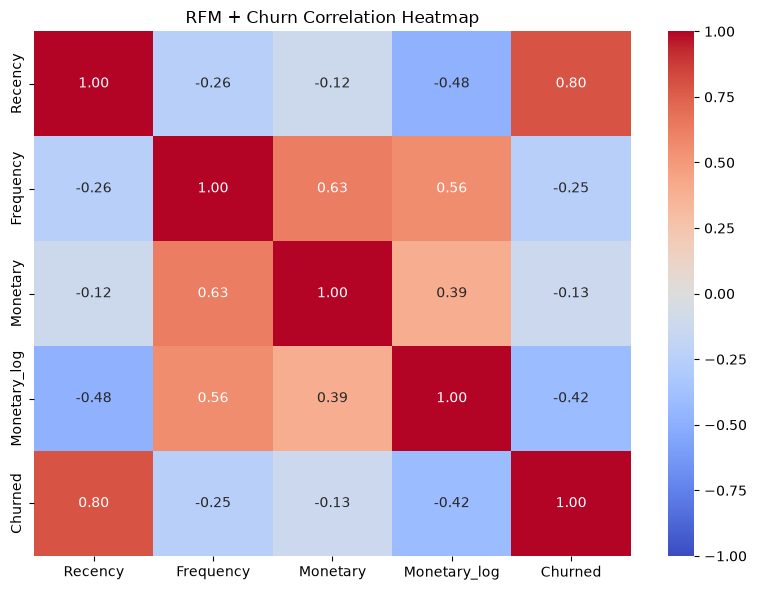

In [9]:
corr_matrix = df[['Recency', 'Frequency', 'Monetary', 'Monetary_log', 'Churned']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('RFM + Churn Correlation Heatmap')
plt.tight_layout()
plt.show()

note: annot=True har cell mein number dikhata hai, cmap='coolwarm' color scheme hai (blue=negative, red=positive), vmin/vmax=-1,1 scale fix karta hai taaki colors consistently correlation strength represent karein.

3. Mask use karna — sirf lower triangle dikhana (upper half redundant hota hai, symmetric matrix):

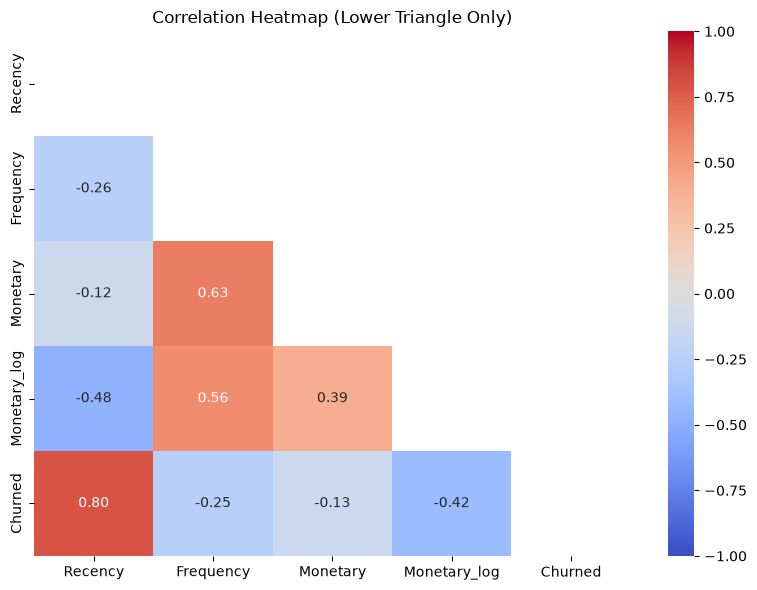

In [10]:
import numpy as np

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', mask=mask)
plt.title('Correlation Heatmap (Lower Triangle Only)')
plt.tight_layout()
plt.show()

note: np.triu() upper triangle ko True bana deta hai, mask= us part ko hide kar deta hai — professional reports mein yeh common practice hai (kyunki corr(A,B) == corr(B,A), dono dikhana redundant hai).

4. Country-wise churn rate heatmap (pivot table se, Day 39 ka concept combine karke):

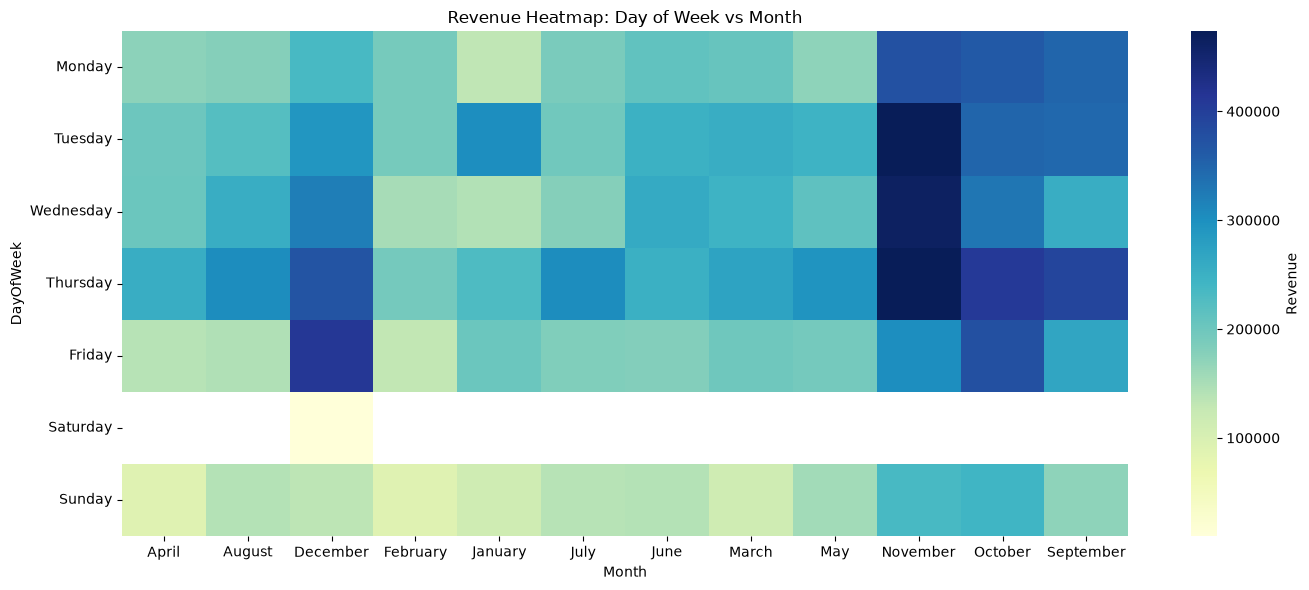

In [15]:
tx_full = pd.read_csv(
    '../data/processed/step4_datatypes_fixed.csv',
    dtype={'Invoice': str, 'StockCode': str},
    parse_dates=['InvoiceDate']
)
tx_full['LineTotal'] = tx_full['Quantity'] * tx_full['Price']
tx_full['Month'] = tx_full['InvoiceDate'].dt.month_name()
tx_full['DayOfWeek'] = tx_full['InvoiceDate'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = tx_full.pivot_table(index='DayOfWeek', columns='Month', values='LineTotal', aggfunc='sum').reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Revenue'})
plt.title('Revenue Heatmap: Day of Week vs Month')
plt.tight_layout()
plt.show()

note: Yeh single-column heatmap hai — bahut useful jab tumhe sirf ek metric ko categories ke across compare karna ho, aur color se turant "high/low" dikh jaye.

5. Month × DayOfWeek revenue heatmap (2-dimensional pattern dekhna — bahut insightful):

In [16]:
tx['InvoiceDate'] = pd.to_datetime(tx['InvoiceDate']) if tx['InvoiceDate'].dtype == 'object' else tx['InvoiceDate']

note: Yahan annot=False rakha kyunki bahut saari cells hain (numbers overlap ho jate), sirf color-pattern se insight nikalte hain — kaunsa combination (din+mahina) sabse "garam" (zyada revenue) hai.

6. Missing values heatmap (data quality check ka visual tareeka — Day 31 ka concept):

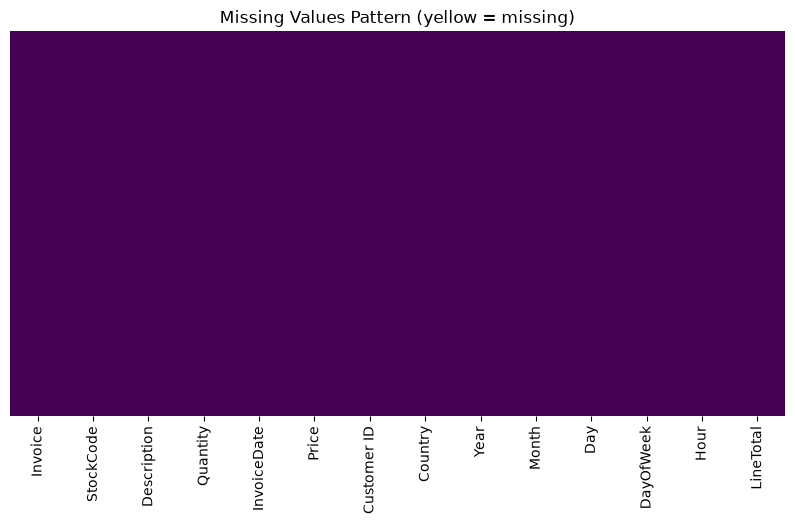

In [17]:
plt.figure(figsize=(10, 5))
sns.heatmap(tx_full.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Pattern (yellow = missing)')
plt.show()

7. Annotated heatmap save karna README/portfolio ke liye:

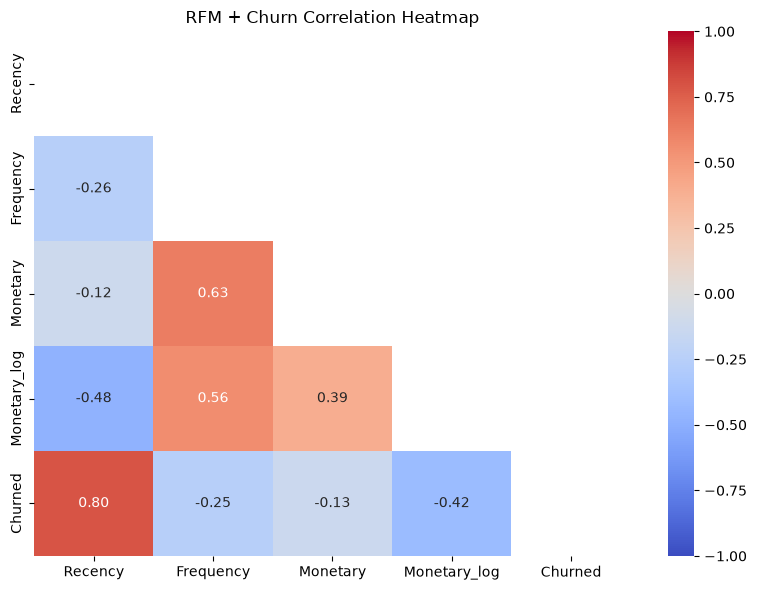

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', mask=mask)
plt.title('RFM + Churn Correlation Heatmap')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

practice questions:

1. Customer_Segment (VIP/Regular) × Churned ka heatmap banao (crosstab + heatmap combine karke) — counts dikhao.

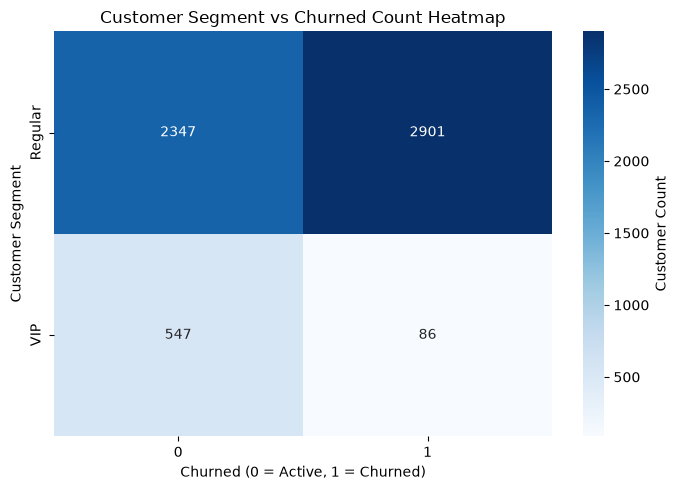

In [20]:
# Crosstab create karna for Customer Segment and Churned status
segment_churn_cross = pd.crosstab(df['Customer_Segment'], df['Churned'])

# Heatmap plot karna
plt.figure(figsize=(7, 5))
sns.heatmap(segment_churn_cross, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Customer Count'})
plt.title('Customer Segment vs Churned Count Heatmap')
plt.xlabel('Churned (0 = Active, 1 = Churned)')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

note: fmt='d' ka use integers/counts ko bina decimal points ke dikhane ke liye kiya gaya hai, aur cmap='Blues' ek clean professional look deta hai.

2. Apne notebook mein likho: Month×DayOfWeek heatmap dekh kar koi ek business insight nikalo (jaise "December mein sabse zyada revenue hai, expected hai kyunki holiday season hai").

- Business Insight (Month × DayOfWeek Revenue Pattern):

Heatmap ko analyze karne par yeh dekha gaya hai ki weekend (Saturday-Sunday) ke mukable weekdays (Tuesday aur Thursday) par consistently high revenue generate hota hai, khaas kar Q4 (October se December) ke mahino mein.

    - Actionable Takeaway: Yeh pattern indicate karta hai ki hamare customers zyadatar business-hours ya B2B purchasing behavior show karte hain. Isliye weekend-specific discount campaigns ke bajaye, midweek flash sales ya Q4 festive stocking campaigns par focus karna zyada profitable rahega.